<a href="https://colab.research.google.com/github/JAYMAN735/ML-Projects/blob/main/new_pds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_excel('/content/all-vehicles-model.xlsx')

In [ ]:
df.head()

,Make,Model,Annual Petroleum Consumption For Fuel Type1,Annual Petroleum Consumption For Fuel Type2,Time to charge at 120V,Time to charge at 240V,City Mpg For Fuel Type1,Unrounded City Mpg For Fuel Type1 (2),City Mpg For Fuel Type2,Unrounded City Mpg For Fuel Type2,...,c240Dscr,charge240b,C240B Dscr,Created On,Modified On,Start-Stop,PHEV City,PHEV Highway,PHEV Combined,baseModel
0,Mercedes-Benz,E350 Convertible,14.875500,0.0,0,0.0,17,17.0031,0,0.0,...,NaN,0.0,NaN,2013-01-01,2016-09-26,NaN,0,0,0,E-Class
1,Porsche,Cayman S,12.935217,0.0,0,0.0,20,19.5372,0,0.0,...,NaN,0.0,NaN,2013-01-01,2016-09-26,NaN,0,0,0,Cayman
2,Honda,Accord,11.018889,0.0,0,0.0,23,23.0818,0,0.0,...,NaN,0.0,NaN,2013-01-01,2016-09-26,NaN,0,0,0,Accord
3,Jeep,Compass 4WD,12.935217,0.0,0,0.0,21,20.7463,0,0.0,...,NaN,0.0,NaN,2013-01-01,2016-09-26,NaN,0,0,0,Compass
4,Toyota,Cressida,15.658421,0.0,0,0.0,17,0.0000,0,0.0,...,NaN,0.0,NaN,2013-01-01,2013-01-01,NaN,0,0,0,Cressida


###Data Cleaning

In [ ]:
df=df.drop(['PHEV Blended','MFR Code','c240Dscr','charge240b','C240B Dscr','Modified On',
            'Start-Stop','PHEV City','PHEV Highway','PHEV Combined','T Charger','S Charger','ATV Type',
            'Fuel Type2','Epa Range For Fuel Type2','Electric motor','You Save/Spend','Guzzler',
            'Unadjusted City Mpg For Fuel Type1','Unadjusted City Mpg For Fuel Type2',
            'Unadjusted Highway Mpg For Fuel Type1','Unadjusted Highway Mpg For Fuel Type2','Range  City For Fuel Type2',
            'Range  Highway For Fuel Type2','2 door luggage volume','4 door luggage volume','MPG Data',
            '2-door passenger volume','4-door passenger volume','GHG Score','GHG Score Alternative Fuel',
            'Highway Mpg For Fuel Type1','Unrounded Highway Mpg For Fuel Type1','Highway Mpg For Fuel Type2',
            'Unrounded Highway Mpg For Fuel Type2','Highway gasoline consumption','Highway electricity consumption',
            'EPA highway utility factor','Hatchback luggage volume','Hatchback passenger volume','Range For Fuel Type1','ID',
            'Annual Fuel Cost For Fuel Type2','Annual Petroleum Consumption For Fuel Type2','Unrounded City Mpg For Fuel Type1 (2)',
            'City Mpg For Fuel Type2','City gasoline consumption', 'EPA model type index','Unrounded City Mpg For Fuel Type2','EPA city utility factor','Co2 Fuel Type1',
            'Co2 Fuel Type2','Co2  Tailpipe For Fuel Type2','Co2  Tailpipe For Fuel Type1','Combined Mpg For Fuel Type1',
            'Unrounded Combined Mpg For Fuel Type1','Combined Mpg For Fuel Type2','Unrounded Combined Mpg For Fuel Type2',
            'Combined electricity consumption','Combined gasoline consumption','Time to charge at 120V','Engine descriptor',
            'EPA Fuel Economy Score','EPA combined utility factor','Fuel Type','Transmission descriptor'],axis=1)

In [ ]:
df.columns.to_list()

['Make',
 'Model',
 'Annual Petroleum Consumption For Fuel Type1',
 'Time to charge at 240V',
 'City Mpg For Fuel Type1',
 'City electricity consumption',
 'Cylinders',
 'Engine displacement',
 'Drive',
 'Annual Fuel Cost For Fuel Type1',
 'Fuel Type1',
 'Range  City For Fuel Type1',
 'Range  Highway For Fuel Type1',
 'Transmission',
 'Vehicle Size Class',
 'Year',
 'Created On',
 'baseModel']

In [ ]:
new_columns = []
for col in df.columns:
  if col == 'Make':
    new_columns.append('Manufacturer')
  else:
    col = col.replace('Type1', 'Type')
    col = col.replace('Type2', 'Type')
    new_columns.append(col)

df.columns = new_columns
display(df.head())

,Manufacturer,Model,Annual Petroleum Consumption For Fuel Type,Time to charge at 240V,City Mpg For Fuel Type,City electricity consumption,Cylinders,Engine displacement,Drive,Annual Fuel Cost For Fuel Type,Fuel Type,Range City For Fuel Type,Range Highway For Fuel Type,Transmission,Vehicle Size Class,Year,Created On,baseModel
0,Mercedes-Benz,E350 Convertible,14.875500,0.0,17,0.0,6.0,3.5,Rear-Wheel Drive,3350,Premium Gasoline,0.0,0.0,Automatic 7-spd,Subcompact Cars,2011,2013-01-01,E-Class
1,Porsche,Cayman S,12.935217,0.0,20,0.0,6.0,3.4,Rear-Wheel Drive,2950,Premium Gasoline,0.0,0.0,Automatic 7-spd,Two Seaters,2012,2013-01-01,Cayman
2,Honda,Accord,11.018889,0.0,23,0.0,4.0,2.4,Front-Wheel Drive,2000,Regular Gasoline,0.0,0.0,Manual 5-spd,Large Cars,2012,2013-01-01,Accord
3,Jeep,Compass 4WD,12.935217,0.0,21,0.0,4.0,2.4,4-Wheel Drive,2350,Regular Gasoline,0.0,0.0,Automatic (variable gear ratios),Sport Utility Vehicle - 4WD,2012,2013-01-01,Compass
4,Toyota,Cressida,15.658421,0.0,17,0.0,6.0,2.8,Rear-Wheel Drive,3550,Premium Gasoline,0.0,0.0,Manual 5-spd,Compact Cars,1987,2013-01-01,Cressida


In [ ]:
df.rename(columns={'Annual Fuel Cost For Fuel Type': 'Annual Fuel Cost','Range  City For Fuel Type':'Range For City','Range  Highway For Fuel Type':'Range For Highway'}, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47523 entries, 0 to 47522
Data columns (total 18 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Manufacturer                                47523 non-null  object 
 1   Model                                       47523 non-null  object 
 2   Annual Petroleum Consumption For Fuel Type  47523 non-null  float64
 3   Time to charge at 240V                      47523 non-null  float64
 4   City Mpg For Fuel Type                      47523 non-null  int64  
 5   City electricity consumption                47523 non-null  float64
 6   Cylinders                                   46722 non-null  float64
 7   Engine displacement                         46724 non-null  float64
 8   Drive                                       46337 non-null  object 
 9   Annual Fuel Cost                            47523 non-null  int64  
 10  Fuel Type 

In [ ]:
print(f"DataFrame shape before dropping duplicates: {df.shape}")
df.drop_duplicates(subset=['Model'], inplace=True)
print(f"DataFrame shape after dropping duplicates: {df.shape}")
display(df.head())

DataFrame shape before dropping duplicates: (47523, 18)
DataFrame shape after dropping duplicates: (5064, 18)


,Manufacturer,Model,Annual Petroleum Consumption For Fuel Type,Time to charge at 240V,City Mpg For Fuel Type,City electricity consumption,Cylinders,Engine displacement,Drive,Annual Fuel Cost,Fuel Type,Range For City,Range For Highway,Transmission,Vehicle Size Class,Year,Created On,baseModel
0,Mercedes-Benz,E350 Convertible,14.875500,0.0,17,0.0,6.0,3.5,Rear-Wheel Drive,3350,Premium Gasoline,0.0,0.0,Automatic 7-spd,Subcompact Cars,2011,2013-01-01,E-Class
1,Porsche,Cayman S,12.935217,0.0,20,0.0,6.0,3.4,Rear-Wheel Drive,2950,Premium Gasoline,0.0,0.0,Automatic 7-spd,Two Seaters,2012,2013-01-01,Cayman
2,Honda,Accord,11.018889,0.0,23,0.0,4.0,2.4,Front-Wheel Drive,2000,Regular Gasoline,0.0,0.0,Manual 5-spd,Large Cars,2012,2013-01-01,Accord
3,Jeep,Compass 4WD,12.935217,0.0,21,0.0,4.0,2.4,4-Wheel Drive,2350,Regular Gasoline,0.0,0.0,Automatic (variable gear ratios),Sport Utility Vehicle - 4WD,2012,2013-01-01,Compass
4,Toyota,Cressida,15.658421,0.0,17,0.0,6.0,2.8,Rear-Wheel Drive,3550,Premium Gasoline,0.0,0.0,Manual 5-spd,Compact Cars,1987,2013-01-01,Cressida


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5064 entries, 0 to 47411
Data columns (total 18 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Manufacturer                                5064 non-null   object 
 1   Model                                       5064 non-null   object 
 2   Annual Petroleum Consumption For Fuel Type  5064 non-null   float64
 3   Time to charge at 240V                      5064 non-null   float64
 4   City Mpg For Fuel Type                      5064 non-null   int64  
 5   City electricity consumption                5064 non-null   float64
 6   Cylinders                                   4619 non-null   float64
 7   Engine displacement                         4619 non-null   float64
 8   Drive                                       4981 non-null   object 
 9   Annual Fuel Cost                            5064 non-null   int64  
 10  Fuel Type       

In [ ]:
make_counts = df['Manufacturer'].value_counts()
display(make_counts)

,count
Manufacturer,
BMW,443
Mercedes-Benz,440
Chevrolet,275
Ford,266
Porsche,196
...,...
Panoz Auto-Development,1
Shelby,1
Azure Dynamics,1


###Remove Manufacturer which have less than 3 Models

In [ ]:
manufacturers_to_remove = make_counts[make_counts <3].index.tolist()

print(f"DataFrame shape before removing manufacturers with count <3: {df.shape}")
df = df[~df['Manufacturer'].isin(manufacturers_to_remove)]
print(f"DataFrame shape after removing manufacturers with count <3: {df.shape}")

display(df.head())

DataFrame shape before removing manufacturers with count <3: (5064, 18)
DataFrame shape after removing manufacturers with count <3: (4997, 18)


,Manufacturer,Model,Annual Petroleum Consumption For Fuel Type,Time to charge at 240V,City Mpg For Fuel Type,City electricity consumption,Cylinders,Engine displacement,Drive,Annual Fuel Cost,Fuel Type,Range For City,Range For Highway,Transmission,Vehicle Size Class,Year,Created On,baseModel
0,Mercedes-Benz,E350 Convertible,14.875500,0.0,17,0.0,6.0,3.5,Rear-Wheel Drive,3350,Premium Gasoline,0.0,0.0,Automatic 7-spd,Subcompact Cars,2011,2013-01-01,E-Class
1,Porsche,Cayman S,12.935217,0.0,20,0.0,6.0,3.4,Rear-Wheel Drive,2950,Premium Gasoline,0.0,0.0,Automatic 7-spd,Two Seaters,2012,2013-01-01,Cayman
2,Honda,Accord,11.018889,0.0,23,0.0,4.0,2.4,Front-Wheel Drive,2000,Regular Gasoline,0.0,0.0,Manual 5-spd,Large Cars,2012,2013-01-01,Accord
3,Jeep,Compass 4WD,12.935217,0.0,21,0.0,4.0,2.4,4-Wheel Drive,2350,Regular Gasoline,0.0,0.0,Automatic (variable gear ratios),Sport Utility Vehicle - 4WD,2012,2013-01-01,Compass
4,Toyota,Cressida,15.658421,0.0,17,0.0,6.0,2.8,Rear-Wheel Drive,3550,Premium Gasoline,0.0,0.0,Manual 5-spd,Compact Cars,1987,2013-01-01,Cressida


###Statistics of Data

In [ ]:
df.describe()

,Annual Petroleum Consumption For Fuel Type,Time to charge at 240V,City Mpg For Fuel Type,City electricity consumption,Cylinders,Engine displacement,Annual Fuel Cost,Range For City,Range For Highway,Year
count,4997.000000,4997.000000,4997.000000,4997.000000,4558.000000,4558.000000,4997.000000,4997.000000,4997.000000,4997.000000
mean,14.176237,0.968145,25.175505,4.522863,6.036200,3.387670,2993.105864,7.162488,6.727743,2009.072243
std,6.258605,3.057789,23.855538,13.453222,2.011762,1.393734,1166.065078,45.101797,42.793868,12.391458
min,0.047081,0.000000,6.000000,0.000000,2.000000,0.600000,0.000000,0.000000,0.000000,1984.000000
25%,11.900400,0.000000,15.000000,0.000000,4.000000,2.200000,2350.000000,0.000000,0.000000,2000.000000
50%,14.875500,0.000000,18.000000,0.000000,6.000000,3.000000,3000.000000,0.000000,0.000000,2012.000000
75%,17.500588,0.000000,22.000000,0.000000,8.000000,4.300000,3600.000000,0.000000,0.000000,2020.000000
max,42.501429,17.000000,153.000000,122.000000,16.000000,8.400000,9600.000000,520.800000,520.500000,2025.000000


###Total Manufacturer count by Model

In [ ]:
make_counts1 = df['Manufacturer'].value_counts()
display(make_counts1)

,count
Manufacturer,
BMW,443
Mercedes-Benz,440
Chevrolet,275
Ford,266
Porsche,196
...,...
RUF Automobile,4
Daihatsu,3
Pagani,3


###Minimum and Maximum values from Manufacturer field

In [ ]:
min_count = make_counts1.min()
max_count = make_counts1.max()

print(f"Minimum vehicle count per make: {min_count}")
print(f"Maximum vehicle count per make: {max_count}")

Minimum vehicle count per make: 3
Maximum vehicle count per make: 443


###Model count based on Manufacturer in class interval of 50

In [ ]:
interval_boundaries = [1, 50, 100, 150, 200, 250, max_count]

interval_labels = ['1-50', '51-100', '101-150','151-200','201-250', f'251-{max_count}']
grouped_makes = pd.cut(make_counts, bins=interval_boundaries, labels=interval_labels, right=True, include_lowest=True)

interval_counts = grouped_makes.value_counts().sort_index()
display(interval_counts)

,count
count,
1-50,101
51-100,20
101-150,6
151-200,4
201-250,0
251-443,4


###Count of Models by Manufacturer

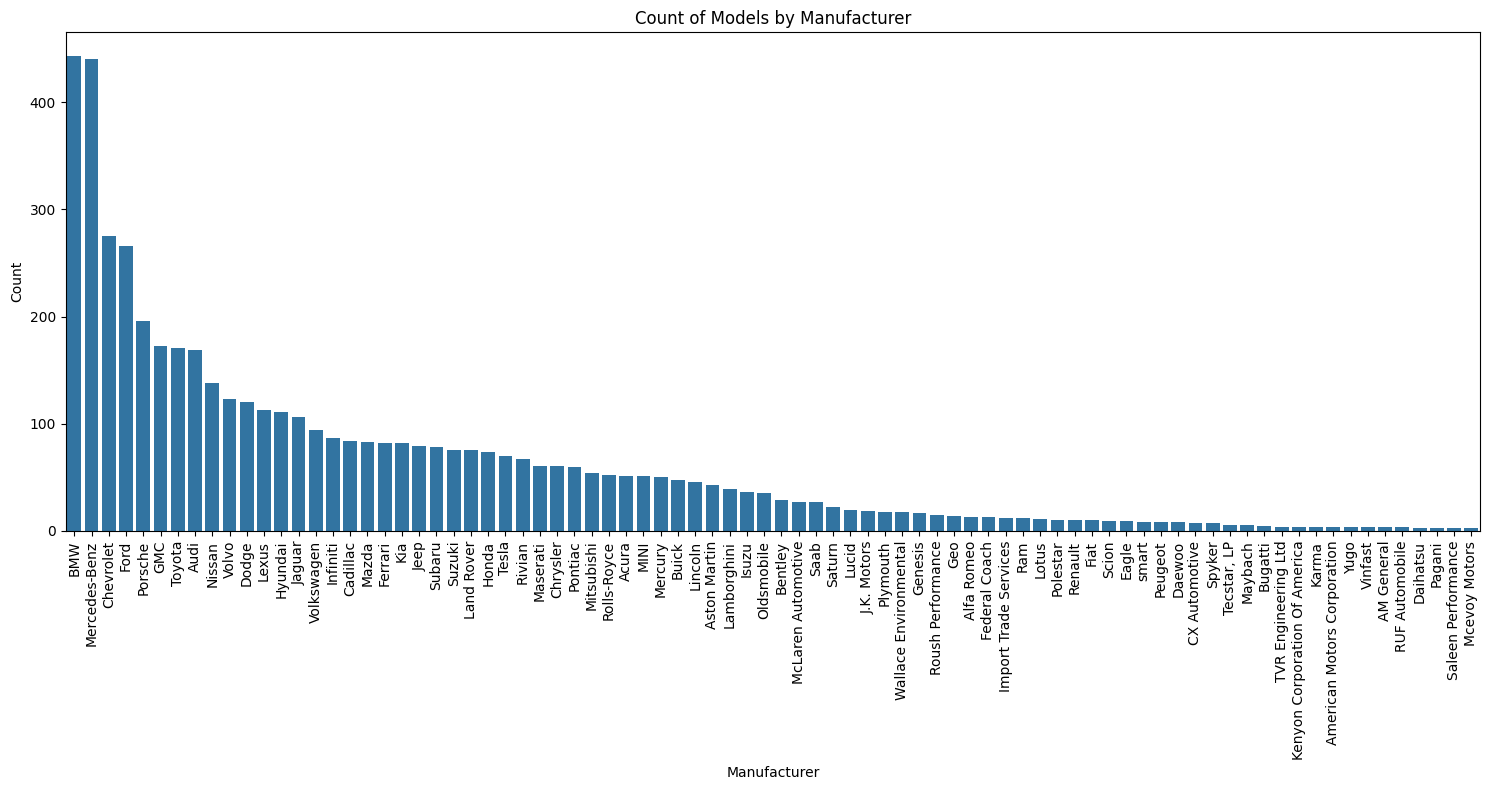

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.barplot(x=make_counts1.index, y=make_counts1.values)
plt.xticks(rotation=90)
plt.xlabel('Manufacturer')
plt.ylabel('Count')
plt.title('Count of Models by Manufacturer')
plt.tight_layout()
plt.show()

###Distribution of Manufacturer by Model Count Interval

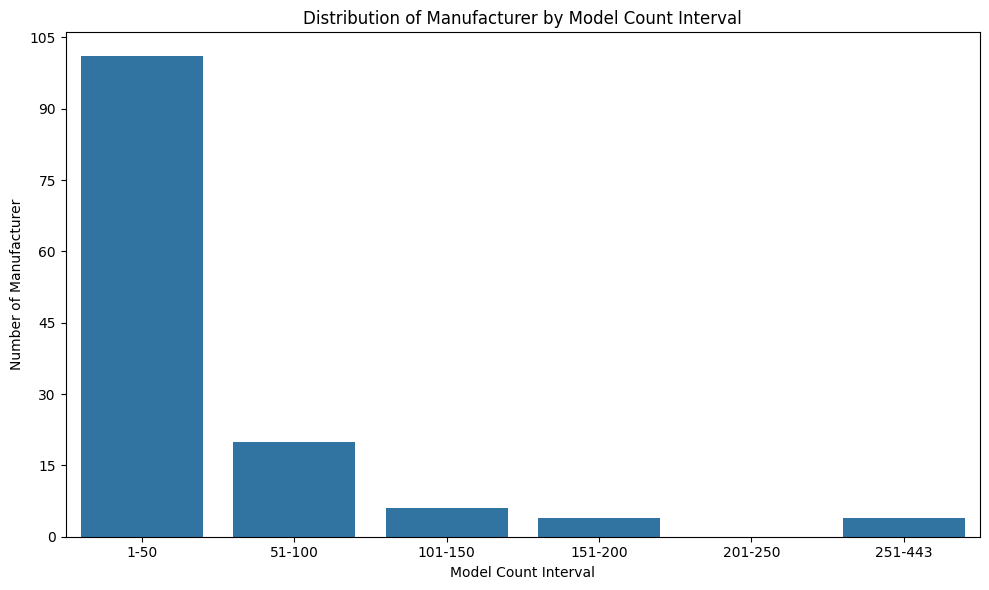

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(10, 6))
sns.barplot(x=interval_counts.index, y=interval_counts.values)
plt.xlabel('Model Count Interval')
plt.ylabel('Number of Manufacturer')
plt.title('Distribution of Manufacturer by Model Count Interval')
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

###Total Manufacturer

In [ ]:
unique_make_count = df['Manufacturer'].nunique()
print(f"The unique count of manufacturers is: {unique_make_count}")

The unique count of manufacturers is: 82


###Vehicle with Maximum and Minimum Annual Fuel Consumption

In [ ]:
max_fuel_consumption_row = df.loc[df['Annual Petroleum Consumption For Fuel Type'].idxmax()]
min_fuel_consumption_row = df.loc[df['Annual Petroleum Consumption For Fuel Type'].idxmin()]

print("\n--- Vehicle with Maximum Annual Fuel Consumption ---")
display(max_fuel_consumption_row[['Manufacturer', 'Model', 'Annual Petroleum Consumption For Fuel Type']])

print("\n--- Vehicle with Minimum Annual Fuel Consumption ---")
display(min_fuel_consumption_row[['Manufacturer', 'Model', 'Annual Petroleum Consumption For Fuel Type']])


--- Vehicle with Maximum Annual Fuel Consumption ---


,21926
Manufacturer,Lamborghini
Model,Countach
Annual Petroleum Consumption For Fuel Type,42.501429



--- Vehicle with Minimum Annual Fuel Consumption ---


,11351
Manufacturer,Honda
Model,Civic Natural Gas
Annual Petroleum Consumption For Fuel Type,0.047081


### Vehicle with Maximum and Minimum Time to charge at 240V

In [ ]:
df_filtered_charge_time = df[df['Time to charge at 240V'] > 0]

max_charge_time_row_filtered = df_filtered_charge_time.loc[df_filtered_charge_time['Time to charge at 240V'].idxmax()]
min_charge_time_row_filtered = df_filtered_charge_time.loc[df_filtered_charge_time['Time to charge at 240V'].idxmin()]

print("\n--- Vehicle with Maximum Time to charge at 240V ---")
display(max_charge_time_row_filtered[['Manufacturer', 'Model', 'Time to charge at 240V']])

print("\n--- Vehicle with Minimum Time to charge at 240V ---")
display(min_charge_time_row_filtered[['Manufacturer', 'Model', 'Time to charge at 240V']])


--- Vehicle with Maximum Time to charge at 240V ---


,44689
Manufacturer,Maserati
Model,Grancabrio Folgore
Time to charge at 240V,17.0



--- Vehicle with Minimum Time to charge at 240V ---


,6124
Manufacturer,Honda
Model,Accord Plug-in Hybrid
Time to charge at 240V,0.67


###Vehicle with Maximum and Minimum City Mpg

In [ ]:
df_zero_charge_time = df[df['Time to charge at 240V'] == 0]

min_city_mpg_zero_charge = df_zero_charge_time['City Mpg For Fuel Type'].min()
max_city_mpg_zero_charge = df_zero_charge_time['City Mpg For Fuel Type'].max()


min_city_mpg_row_zero_charge = df_zero_charge_time.loc[df_zero_charge_time['City Mpg For Fuel Type'].idxmin()]
max_city_mpg_row_zero_charge = df_zero_charge_time.loc[df_zero_charge_time['City Mpg For Fuel Type'].idxmax()]



print("\n--- Vehicle with Minimum City Mpg ---")
display(min_city_mpg_row_zero_charge[['Manufacturer', 'Model', 'City Mpg For Fuel Type']])

print("\n--- Vehicle with Maximum City Mpg ---")
display(max_city_mpg_row_zero_charge[['Manufacturer', 'Model', 'City Mpg For Fuel Type']])


--- Vehicle with Minimum City Mpg ---


,21926
Manufacturer,Lamborghini
Model,Countach
City Mpg For Fuel Type,6



--- Vehicle with Maximum City Mpg ---


,37581
Manufacturer,MINI
Model,MiniE
City Mpg For Fuel Type,102


###Vehicle with Maximum and Minimum City Electricity Consumption

In [ ]:
df_filtered_electricity_consumption = df[df['City electricity consumption'] > 0]

max_electricity_consumption_row = df_filtered_electricity_consumption.loc[df_filtered_electricity_consumption['City electricity consumption'].idxmax()]
min_electricity_consumption_row = df_filtered_electricity_consumption.loc[df_filtered_electricity_consumption['City electricity consumption'].idxmin()]

print("\n--- Vehicle with Maximum City Electricity Consumption ---")
display(max_electricity_consumption_row[['Manufacturer', 'Model', 'City electricity consumption']])

print("\n--- Vehicle with Minimum City Electricity Consumption ---")
display(min_electricity_consumption_row[['Manufacturer', 'Model', 'City electricity consumption']])


--- Vehicle with Maximum City Electricity Consumption ---


,4938
Manufacturer,Chevrolet
Model,S10 Electric
City electricity consumption,122.0



--- Vehicle with Minimum City Electricity Consumption ---


,27939
Manufacturer,Hyundai
Model,Ioniq 6 Long range RWD (18 inch Wheels)
City electricity consumption,21.6301


###Vehicles with City electricity consumption greater than the average

In [ ]:
avg_city_electricity_consumption = df_filtered_electricity_consumption['City electricity consumption'].mean()

print(f"Average City electricity consumption for EV/Hybrid vehicles: {avg_city_electricity_consumption:.2f}")

vehicles_above_avg_electricity_consumption = df_filtered_electricity_consumption[df_filtered_electricity_consumption['City electricity consumption'] > avg_city_electricity_consumption]

print("\n--- Vehicles with City electricity consumption greater than the average ---")
display(vehicles_above_avg_electricity_consumption[['Manufacturer', 'Model', 'City electricity consumption']])

Average City electricity consumption for EV/Hybrid vehicles: 40.21

--- Vehicles with City electricity consumption greater than the average ---


,Manufacturer,Model,City electricity consumption
29,Mercedes-Benz,AMG EQE 4matic Plus (SUV),42.8949
32,BMW,XM,73.0000
282,Karma,Revero GT (21-inch wheels),47.0000
320,Rivian,R1S 22 inch Performance Dual Large,42.3512
326,Porsche,Panamera 4 e-Hybrid Executive,69.0000
...,...,...,...
45793,Rivian,R1S Dual Large (21in),41.2352
46285,Ferrari,296 GTB,76.0000
46526,Porsche,Panamera 4S E-Hybrid/Exec/ST,68.0000
47231,McLaren Automotive,Artura,90.0000


###Number of Cylinders per Model

In [ ]:
cylinders_data = df.groupby(['Manufacturer', 'Model'])['Cylinders'].unique().reset_index()

# Display the results
display(cylinders_data.head(10))

,Manufacturer,Model,Cylinders
0,AM General,DJ Po Vehicle 2WD,[4.0]
1,AM General,FJ8c Post Office,[6.0]
2,AM General,Post Office DJ5 2WD,[4.0]
3,AM General,Post Office DJ8 2WD,[6.0]
4,Acura,2.2CL/3.0CL,[6.0]
5,Acura,2.3CL/3.0CL,[6.0]
6,Acura,2.5TL,[5.0]
7,Acura,2.5TL/3.2TL,[5.0]
8,Acura,3.2CL,[6.0]
9,Acura,3.2TL,[6.0]


###Maximum Engine Displacement per Manufacturer

In [ ]:
max_displacement_by_manufacturer = df.groupby('Manufacturer')['Engine displacement'].max()

In [ ]:
max_displacement_df = max_displacement_by_manufacturer.reset_index()
max_displacement_df.columns = ['Manufacturer', 'Maximum Engine Displacement']

# Format the 'Maximum Engine Displacement' column
max_displacement_df['Maximum Engine Displacement'] = max_displacement_df['Maximum Engine Displacement'].apply(lambda x: f'{x:.1f}L' if pd.notna(x) else 'No data available')

display(max_displacement_df)

,Manufacturer,Maximum Engine Displacement
0,AM General,4.2L
1,Acura,3.7L
2,Alfa Romeo,4.7L
3,American Motors Corporation,4.2L
4,Aston Martin,6.0L
...,...,...
77,Volkswagen,6.0L
78,Volvo,3.2L
79,Wallace Environmental,6.0L
80,Yugo,1.3L


###Distribution of Model Drive Types

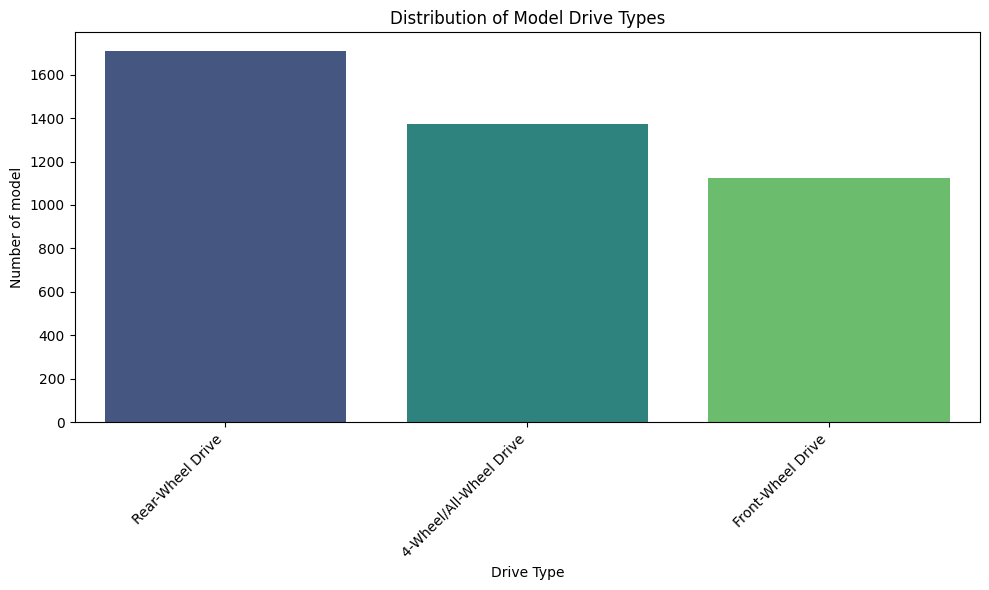

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy of the DataFrame for plotting to avoid modifying the original df
df_plot = df.copy()

# Combine '4-Wheel Drive' and 'All-Wheel Drive' into a single category
df_plot['Drive_Grouped'] = df_plot['Drive'].replace({
    'All-Wheel Drive': '4-Wheel/All-Wheel Drive',
    '4-Wheel Drive': '4-Wheel/All-Wheel Drive'
})

# Filter for the specific categories requested
valid_drive_types = ['Rear-Wheel Drive', 'Front-Wheel Drive', '4-Wheel/All-Wheel Drive']
drive_counts = df_plot['Drive_Grouped'].value_counts()
filtered_drive_counts = drive_counts[drive_counts.index.isin(valid_drive_types)]

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=filtered_drive_counts.index, y=filtered_drive_counts.values, palette='viridis', hue=filtered_drive_counts.index, legend=False)
plt.xlabel('Drive Type')
plt.ylabel('Number of model')
plt.title('Distribution of Model Drive Types')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Average Annual Fuel Cost by Manufacturer

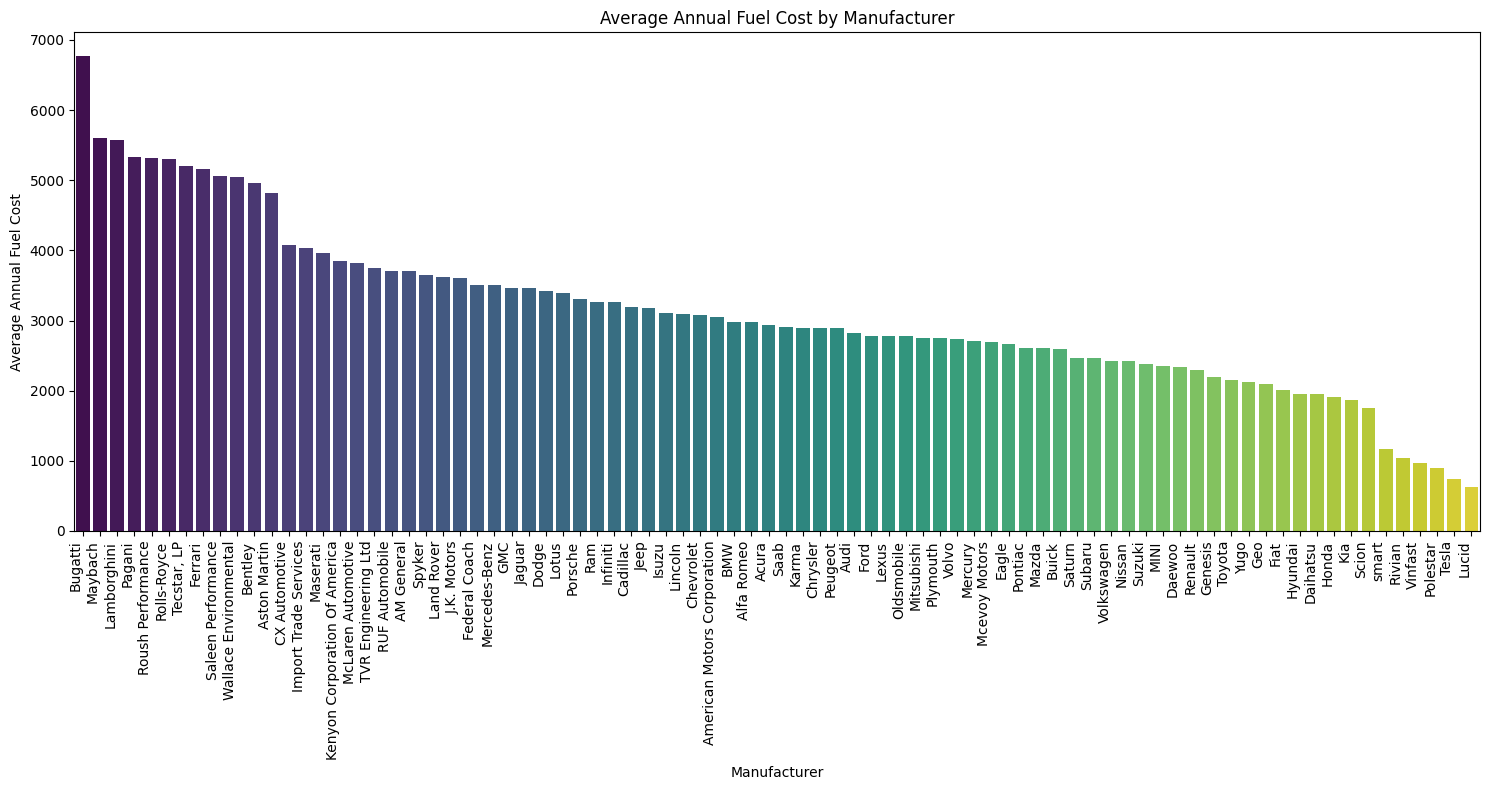

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average annual fuel cost for each manufacturer
avg_fuel_cost_by_manufacturer = df.groupby('Manufacturer')['Annual Fuel Cost'].mean().sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(15, 8))
sns.barplot(x=avg_fuel_cost_by_manufacturer.index, y=avg_fuel_cost_by_manufacturer.values, palette='viridis', hue=avg_fuel_cost_by_manufacturer.index, legend=False)
plt.xlabel('Manufacturer')
plt.ylabel('Average Annual Fuel Cost')
plt.title('Average Annual Fuel Cost by Manufacturer')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

###Distribution of Fuel Types

In [ ]:
unique_fuel_types = df['Fuel Type'].unique()
print("Unique Fuel Types:")
display(unique_fuel_types)

Unique Fuel Types:


array(['Premium Gasoline', 'Regular Gasoline', 'Diesel', 'Electricity',
       'Natural Gas', 'Hydrogen', 'Midgrade Gasoline'], dtype=object)

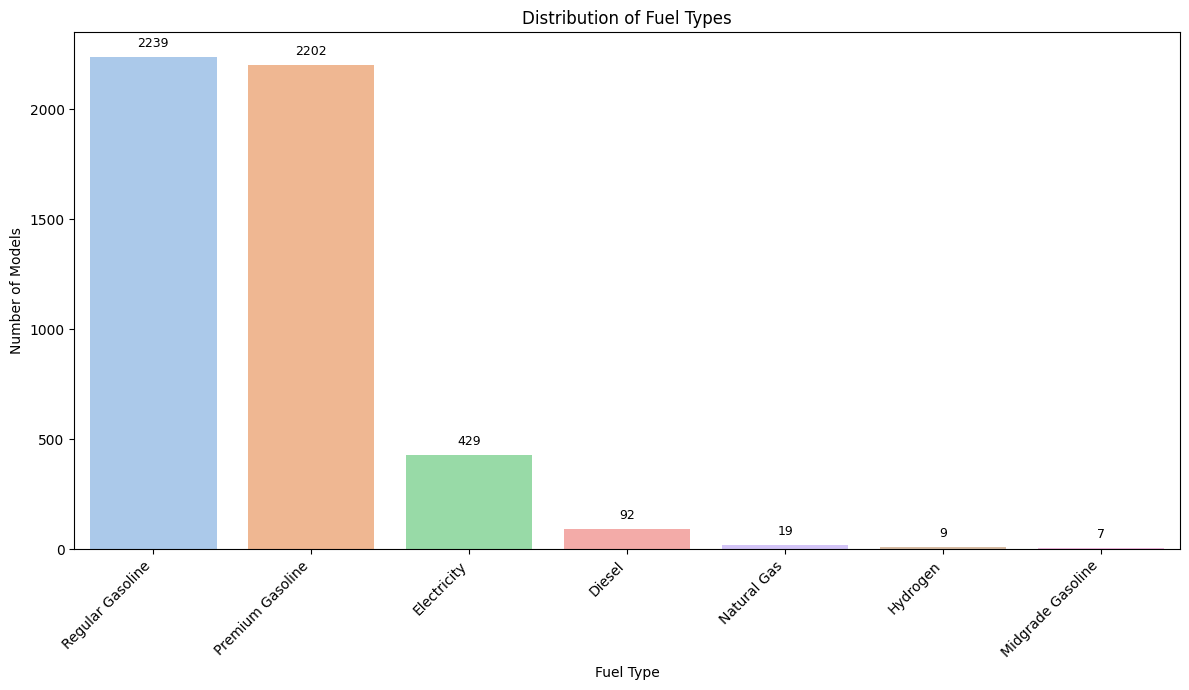

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for 'Fuel Type'
fuel_type_counts = df['Fuel Type'].value_counts()

# Create the bar chart with normal y-axis
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=fuel_type_counts.index, y=fuel_type_counts.values, palette='pastel', hue=fuel_type_counts.index, legend=False)
plt.xlabel('Fuel Type')
plt.ylabel('Number of Models')
plt.title('Distribution of Fuel Types')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

###Average City vs. Highway Range by Manufacturer

In [ ]:
df_filtered_ranges = df[(df['Range For City'] > 0) & (df['Range For Highway'] > 0)]
average_ranges_by_manufacturer = df_filtered_ranges.groupby('Manufacturer')[['Range For City', 'Range For Highway']].mean().reset_index()
display(average_ranges_by_manufacturer)

,Manufacturer,Range For City,Range For Highway
0,Audi,219.358200,221.707700
1,BMW,195.984500,184.011300
2,Chevrolet,171.450000,146.100000
3,Fiat,90.000000,76.600000
4,Ford,285.068845,246.375082
5,Genesis,260.000000,218.600000
6,Honda,93.255000,76.230000
7,Hyundai,252.500000,193.075000
8,Jaguar,244.815350,220.892400
9,Kia,259.240000,201.360000


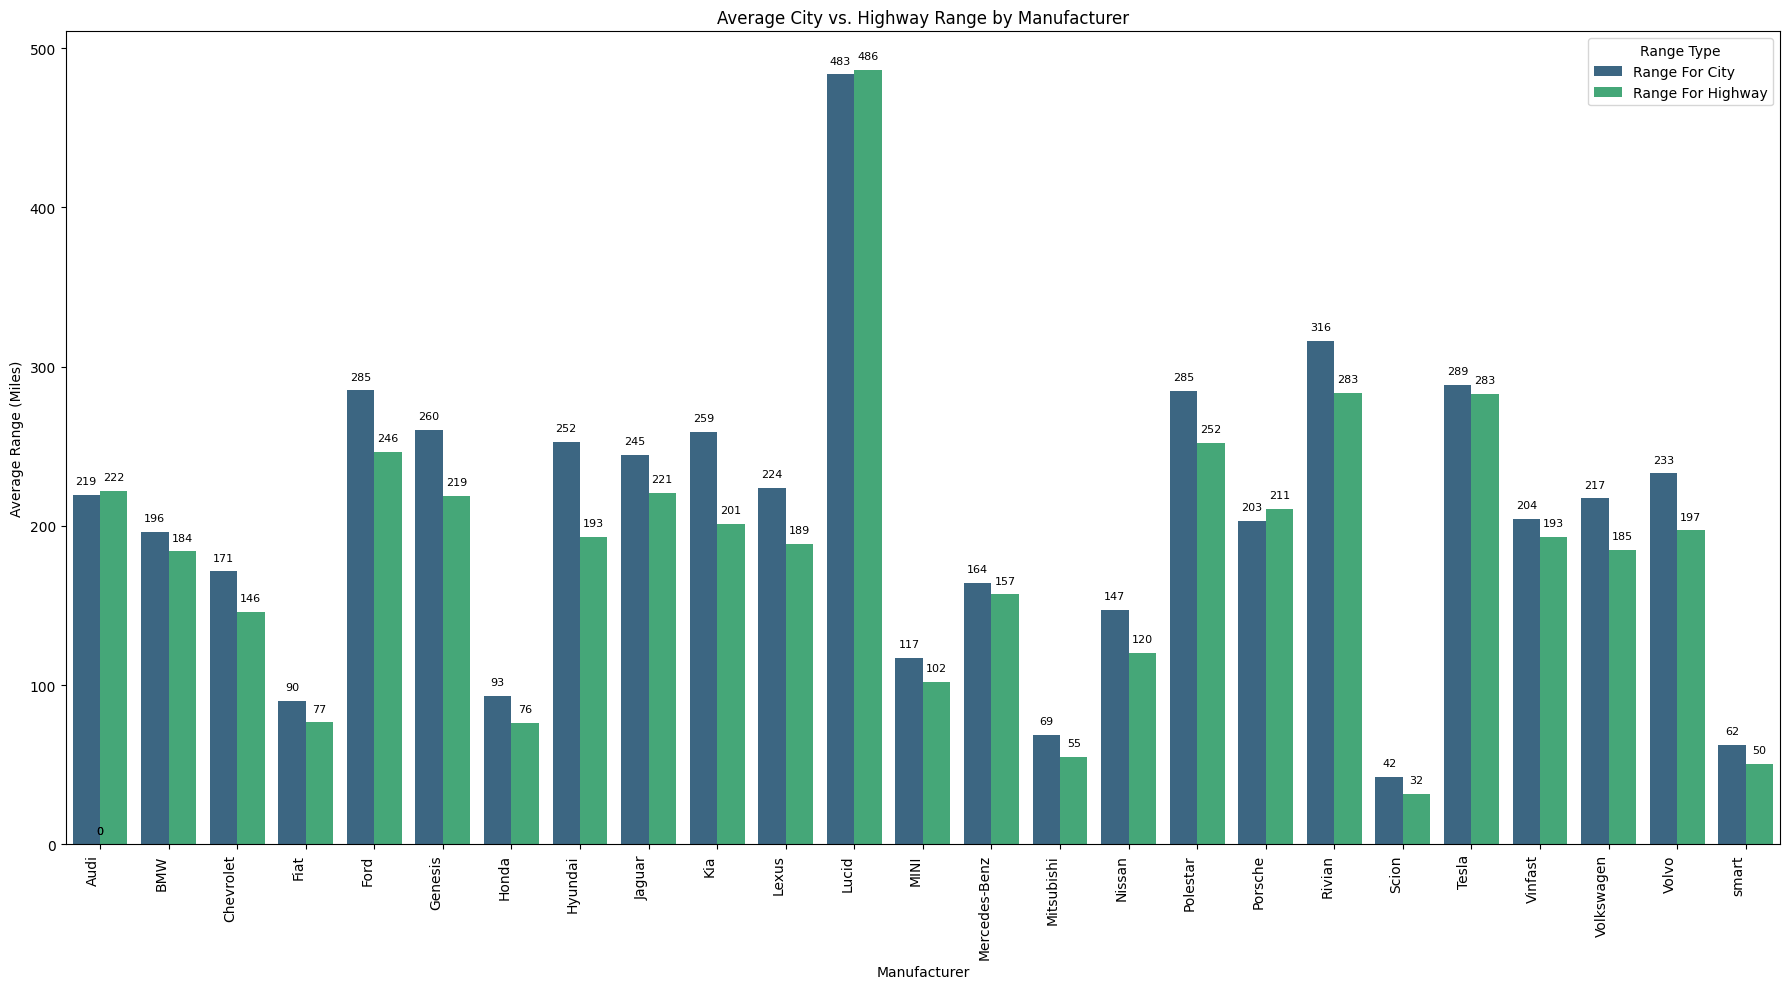

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for grouped bar chart
df_melted = average_ranges_by_manufacturer.melt(id_vars='Manufacturer',
                                                value_vars=['Range For City', 'Range For Highway'],
                                                var_name='Range Type',
                                                value_name='Average Range')

# Create the grouped bar chart
plt.figure(figsize=(18, 10))
ax = sns.barplot(x='Manufacturer', y='Average Range', hue='Range Type', data=df_melted, palette='viridis')

# Set labels and title
plt.xlabel('Manufacturer')
plt.ylabel('Average Range (Miles)')
plt.title('Average City vs. Highway Range by Manufacturer')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90, ha='right')
plt.legend(title='Range Type')

# Add labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=8)

plt.tight_layout()
plt.show()

###Distribution of Transmission Types by Drive Type

In [ ]:
transmission_mode = df['Transmission'].mode()[0]
print(f"The mode of the 'Transmission' column is: {transmission_mode}")

The mode of the 'Transmission' column is: Automatic 4-spd


In [ ]:
df['Transmission'] = df['Transmission'].fillna(transmission_mode)
print("Missing values in 'Transmission' column have been imputed with the mode.")

Missing values in 'Transmission' column have been imputed with the mode.


In [ ]:
df_plot = df.copy()
df_plot['Drive_Grouped'] = df_plot['Drive'].replace({
    'All-Wheel Drive': '4-Wheel/All-Wheel Drive',
    '4-Wheel Drive': '4-Wheel/All-Wheel Drive'
})

In [ ]:
# Combine '2-Wheel Drive' into 'Front-Wheel Drive'
df_plot.loc[:, 'Drive_Grouped'] = df_plot['Drive_Grouped'].replace({'2-Wheel Drive': 'Front-Wheel Drive'})

# Remove 'Part-time 4-Wheel Drive'
df_plot = df_plot[df_plot['Drive_Grouped'] != 'Part-time 4-Wheel Drive']

# Combine '4-Wheel or All-Wheel Drive' and '4-Wheel/All-Wheel Drive'
df_plot.loc[:, 'Drive_Grouped'] = df_plot['Drive_Grouped'].replace({'4-Wheel or All-Wheel Drive': '4-Wheel/All-Wheel Drive'})

print("Unique values and their counts in 'Drive_Grouped' column after modifications:")
display(df_plot['Drive_Grouped'].value_counts())

Unique values and their counts in 'Drive_Grouped' column after modifications:


,count
Drive_Grouped,
4-Wheel/All-Wheel Drive,1937
Rear-Wheel Drive,1709
Front-Wheel Drive,1153


In [ ]:
import numpy as np

# Identify all automatic transmission types based on their starting string or common patterns
# Exclude 'Manual' transmissions that might contain 'Auto' in their description if any exist (though unlikely here)
automatic_patterns = [
    'Automatic',
    'Auto',
    'Automatic (A1)', 'Automatic (A2)', 'Automatic (AM-S6)', 'Automatic (AM-S7)',
    'Automatic (AM-S8)', 'Automatic (AM-S9)', 'Automatic (AM5)', 'Automatic (AM6)',
    'Automatic (AM7)', 'Automatic (AM8)', 'Automatic (AV-S10)', 'Automatic (AV-S6)',
    'Automatic (AV-S7)', 'Automatic (AV-S8)', 'Automatic (variable gear ratios)',
    'Automatic (variable gear ratios CVT)', 'Automatic (variable gear ratios) XMSN'
]

# Create a copy of the list of current unique transmission types to see what will be affected
current_unique_transmissions = df['Transmission'].unique()

# Convert to a list of strings for easier checking
current_trans_list = [str(x) for x in current_unique_transmissions if pd.notna(x)]

# Find all transmissions that match any of the automatic patterns
automatic_transmissions_to_replace = []
for trans_type in current_trans_list:
    if any(pattern in trans_type for pattern in automatic_patterns) and 'Manual' not in trans_type:
        automatic_transmissions_to_replace.append(trans_type)

# Replace these specific automatic types with a general 'Automatic'
df['Transmission'] = df['Transmission'].replace(automatic_transmissions_to_replace, 'Automatic')

print("Unique values in 'Transmission' column after consolidation:")
display(df['Transmission'].unique())

Unique values in 'Transmission' column after consolidation:


array(['Automatic', 'Manual 5-spd', 'Manual 4-spd', 'Manual 6-spd',
       'Manual 3-spd', 'Manual 4-spd Doubled', 'Manual 7-spd'],
      dtype=object)

In [ ]:
# Identify all manual transmission types based on their starting string or common patterns
manual_patterns = [
    'Manual',
    'Manual 5-spd', 'Manual 4-spd', 'Manual 6-spd',
    'Manual 3-spd', 'Manual 4-spd Doubled', 'Manual 7-spd'
]

# Find all transmissions that match any of the manual patterns
manual_transmissions_to_replace = []
for trans_type in df['Transmission'].unique():
    if any(pattern in str(trans_type) for pattern in manual_patterns) and 'Automatic' not in str(trans_type):
        manual_transmissions_to_replace.append(trans_type)

# Replace these specific manual types with a general 'Manual'
df['Transmission'] = df['Transmission'].replace(manual_transmissions_to_replace, 'Manual')

print("Unique values in 'Transmission' column after manual consolidation:")
display(df['Transmission'].unique())

Unique values in 'Transmission' column after manual consolidation:


array(['Automatic', 'Manual'], dtype=object)

In [ ]:
drive_transmission_crosstab = pd.crosstab(df_plot['Drive_Grouped'], df['Transmission'])
display(drive_transmission_crosstab)

Transmission,Automatic,Manual
Drive_Grouped,,
4-Wheel/All-Wheel Drive,1726,211
Front-Wheel Drive,866,287
Rear-Wheel Drive,1398,311


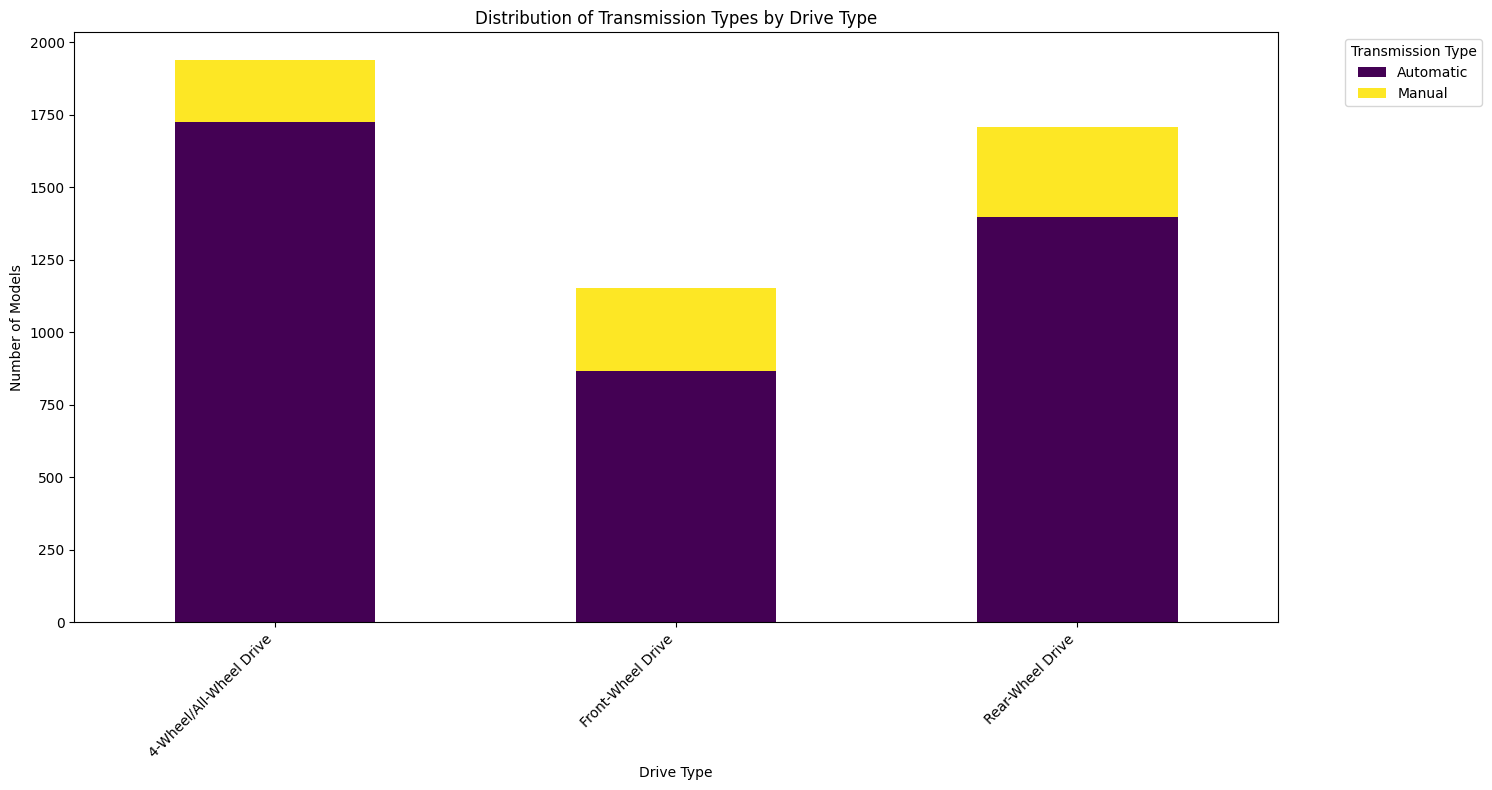

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the stacked bar chart
drive_transmission_crosstab.plot(kind='bar', stacked=True, figsize=(15, 8), cmap='viridis')
plt.xlabel('Drive Type')
plt.ylabel('Number of Models')
plt.title('Distribution of Transmission Types by Drive Type')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Transmission Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

###Number of Unique Manufacturers per Year (2000-2024)

In [ ]:
min_year = df['Year'].min()
max_year = df['Year'].max()

print(f"Minimum Year: {min_year}")
print(f"Maximum Year: {max_year}")

Minimum Year: 1984
Maximum Year: 2025


In [ ]:
total_manufacturers_per_year = df.groupby('Year')['Manufacturer'].nunique().reset_index()
total_manufacturers_per_year.rename(columns={'Manufacturer': 'Number of Manufacturers'}, inplace=True)
display(total_manufacturers_per_year.head())

,Year,Number of Manufacturers
0,1984,36
1,1985,32
2,1986,31
3,1987,31
4,1988,31


In [ ]:
filtered_manufacturers_per_year = total_manufacturers_per_year[
    (total_manufacturers_per_year['Year'] >= 2000) &
    (total_manufacturers_per_year['Year'] <= 2024)
]

# Display the filtered DataFrame to verify
display(filtered_manufacturers_per_year.head())

,Year,Number of Manufacturers
16,2000,27
17,2001,31
18,2002,33
19,2003,32
20,2004,30


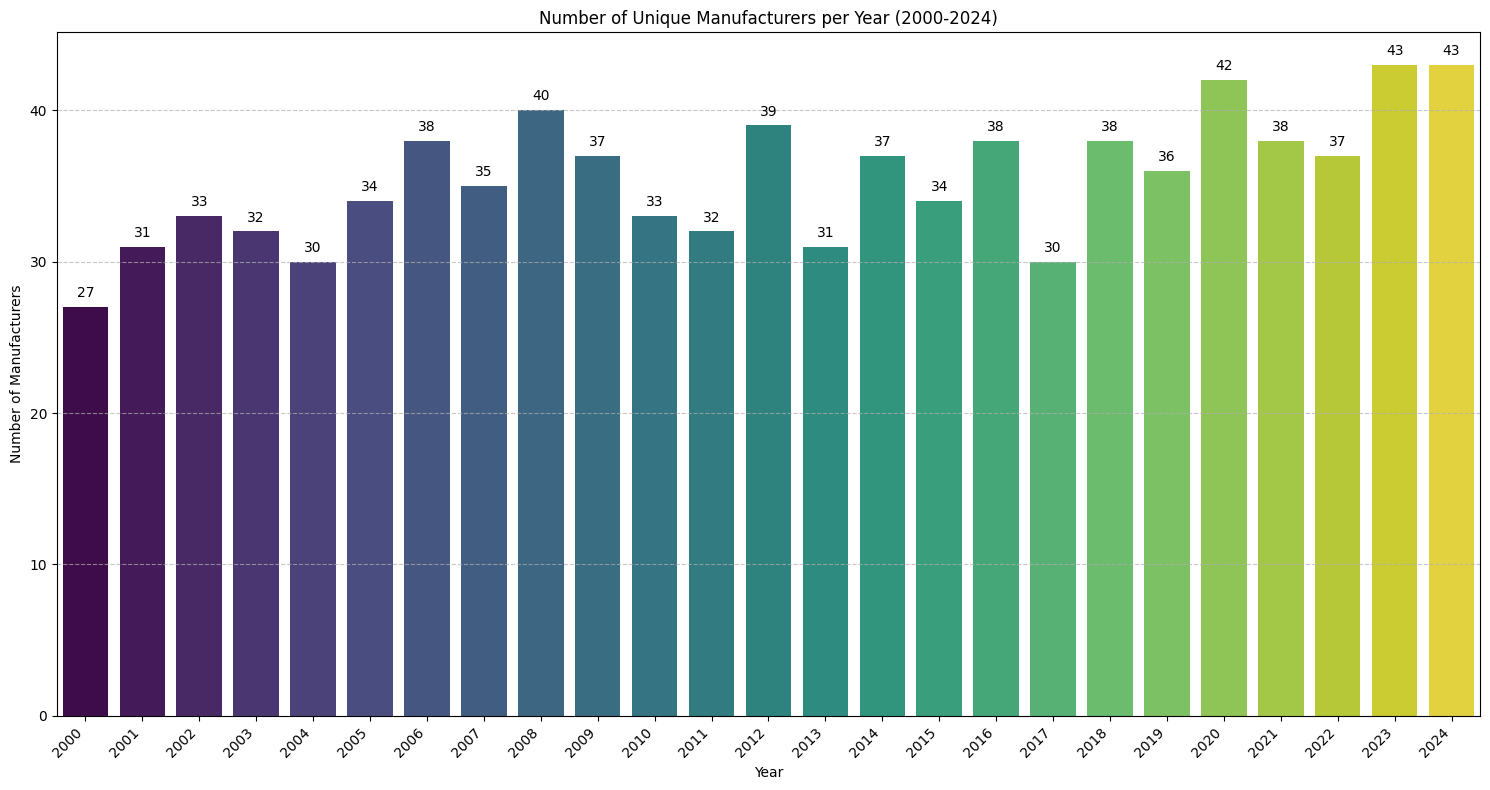

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Year', y='Number of Manufacturers', data=filtered_manufacturers_per_year, hue='Year', palette='viridis', legend=False)

# Add data labels to each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

plt.title('Number of Unique Manufacturers per Year (2000-2024)')
plt.xlabel('Year')
plt.ylabel('Number of Manufacturers')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_manual = df[df['Transmission'] == 'Manual']

print("First few rows of df_manual:")
display(df_manual.head())

print(f"Shape of df_manual: {df_manual.shape}")

First few rows of df_manual:


,Manufacturer,Model,Annual Petroleum Consumption For Fuel Type,Time to charge at 240V,City Mpg For Fuel Type,City electricity consumption,Cylinders,Engine displacement,Drive,Annual Fuel Cost,Fuel Type,Range For City,Range For Highway,Transmission,Vehicle Size Class,Year,Created On,baseModel
2,Honda,Accord,11.018889,0.0,23,0.0,4.0,2.4,Front-Wheel Drive,2000,Regular Gasoline,0.0,0.0,Manual,Large Cars,2012,2013-01-01,Accord
4,Toyota,Cressida,15.658421,0.0,17,0.0,6.0,2.8,Rear-Wheel Drive,3550,Premium Gasoline,0.0,0.0,Manual,Compact Cars,1987,2013-01-01,Cressida
19,Volvo,C70 Convertible,14.875500,0.0,18,0.0,5.0,2.3,Front-Wheel Drive,3350,Premium Gasoline,0.0,0.0,Manual,Subcompact Cars,2000,2013-01-01,C70
21,Dodge,Dakota Pickup 4WD,19.834000,0.0,13,0.0,8.0,4.7,4-Wheel or All-Wheel Drive,3600,Regular Gasoline,0.0,0.0,Manual,Standard Pickup Trucks 4WD,2003,2013-01-01,Dakota Pickup
22,Scion,xB,10.625357,0.0,26,0.0,4.0,1.5,Front-Wheel Drive,1900,Regular Gasoline,0.0,0.0,Manual,Small Station Wagons,2006,2013-01-01,xB


Shape of df_manual: (843, 18)


###Maximum Engine Displacement by Manufacturer (Manual Transmission Vehicles)

In [ ]:
max_displacement_manual_model = df_manual.groupby('Model')['Engine displacement'].max().reset_index()

print("Maximum engine displacement for each model with manual transmission:")
display(max_displacement_manual_model.head())

Maximum engine displacement for each model with manual transmission:


,Model,Engine displacement
0,100,2.8
1,128ci Convertible,3.0
2,128i Convertible,3.0
3,135i,3.0
4,164,3.0


In [ ]:
max_displacement_manual_manufacturer = df_manual.groupby('Manufacturer')['Engine displacement'].max().reset_index()
max_displacement_manual_manufacturer.rename(columns={'Engine displacement': 'Maximum Engine Displacement'}, inplace=True)

print("Maximum engine displacement for each manufacturer with manual transmission:")
display(max_displacement_manual_manufacturer.head())

Maximum engine displacement for each manufacturer with manual transmission:


,Manufacturer,Maximum Engine Displacement
0,Acura,3.7
1,Alfa Romeo,3.0
2,American Motors Corporation,4.2
3,Aston Martin,5.9
4,Audi,5.2


In [ ]:
top_manual_displacement_models = max_displacement_manual_model.sort_values(by='Engine displacement', ascending=False).head(10)

print("\n--- Top 10 Models with Highest Engine Displacement (Manual Transmission) ---")
display(top_manual_displacement_models)


--- Top 10 Models with Highest Engine Displacement (Manual Transmission) ---


,Model,Engine displacement
806,Viper SRT,8.4
805,Viper Coupe,8.0
803,Viper,8.0
804,Viper Convertible,8.0
695,Sierra 2500 4WD,6.5
269,Challenger SRT8,6.4
270,Challenger Widebody,6.4
215,C15 Pickup 2WD,6.2
784,V10 (K10) Pickup 4WD,6.2
268,Challenger SRT Widebody,6.2


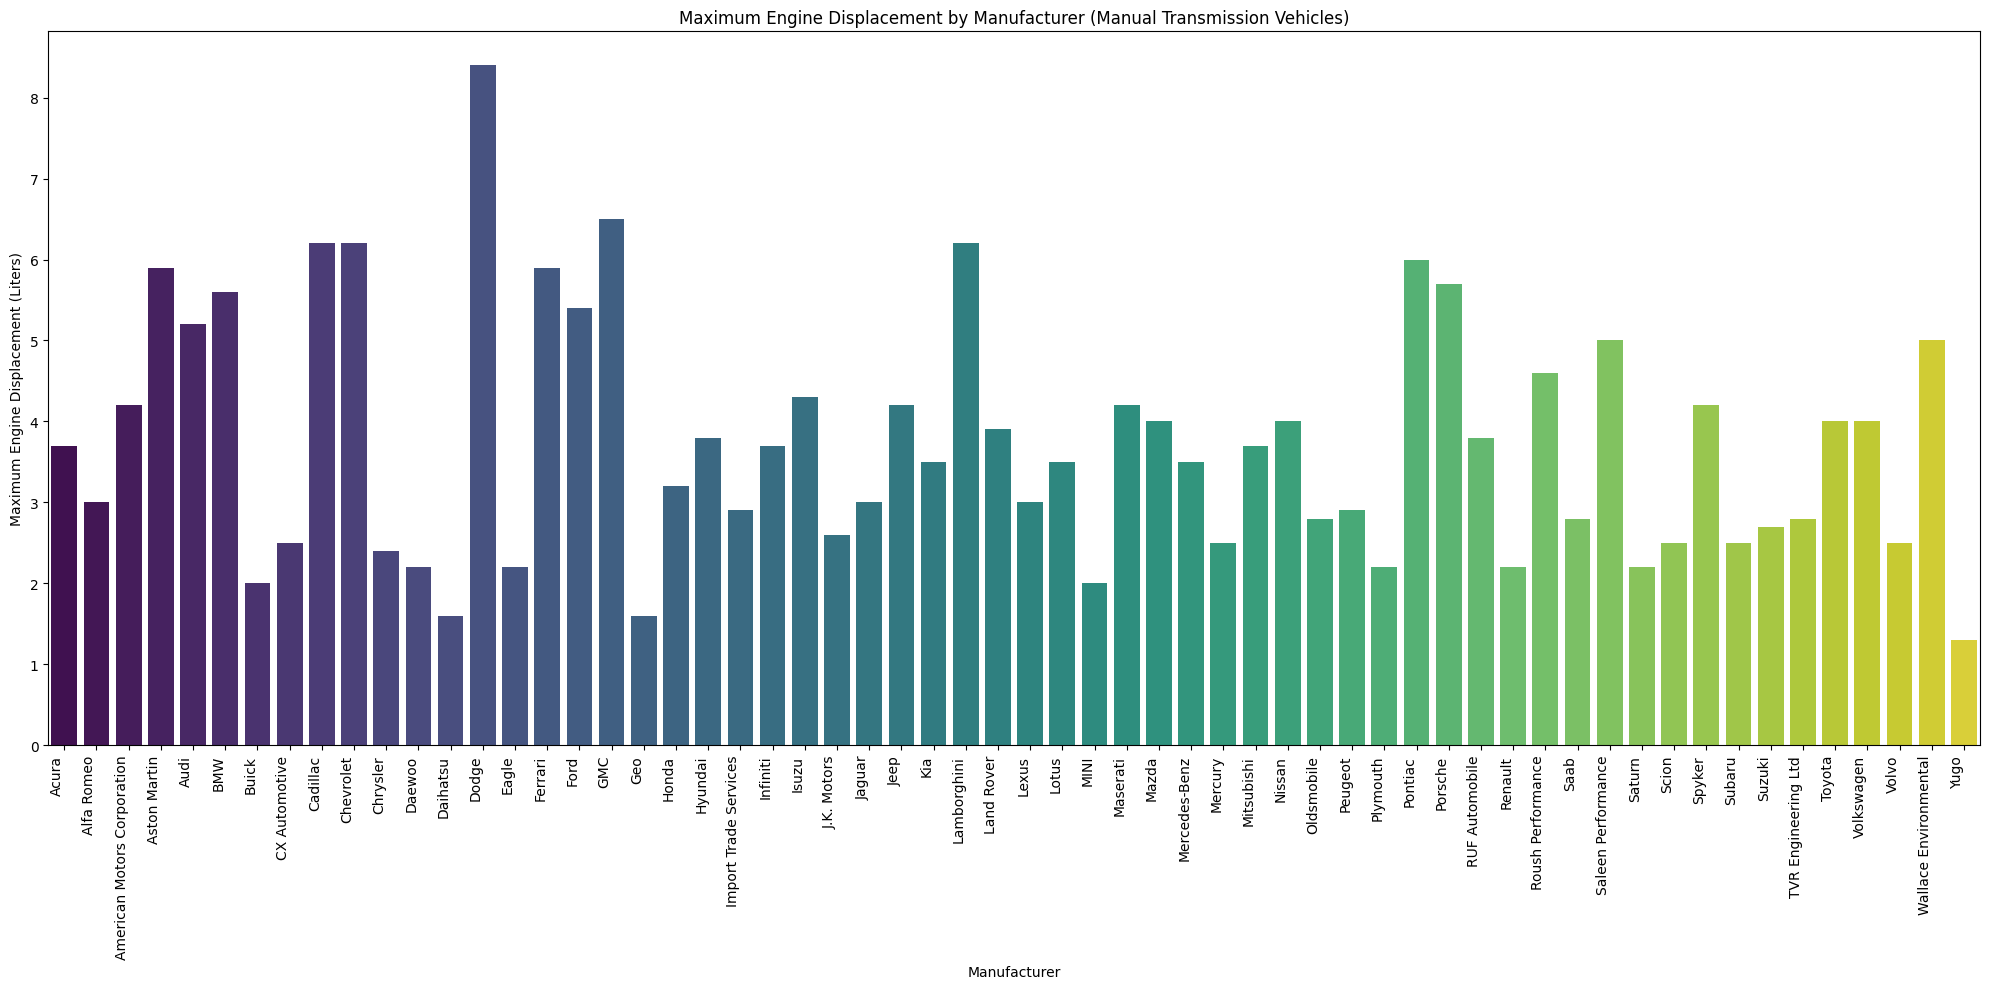

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 10))
sns.barplot(x='Manufacturer', y='Maximum Engine Displacement', data=max_displacement_manual_manufacturer, palette='viridis', hue='Manufacturer', legend=False)
plt.title('Maximum Engine Displacement by Manufacturer (Manual Transmission Vehicles)')
plt.xlabel('Manufacturer')
plt.ylabel('Maximum Engine Displacement (Liters)')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()